The goal of this Jupyter Notebook is to plot the signifcant coefficient of the regdhfe by market for each output variable.

In [1]:
import pandas as pd

# Import raw csv files

df_won = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_group/reg_won_t_minus_1_by_item_group.csv')

df_last = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_group/reg_last_bid_by_item_group.csv')

df_age = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_group/reg_age_by_item_group.csv')

df_lim_firm = pd.read_csv('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/data/raw/item_group/reg_limited_firm_by_item_group.csv')

In [2]:
# Merge csv files and drop duplicates

df_won = df_won.loc[df_won['Variable'] != '1.flagvencedor#c.MV']
df_last = df_last.loc[df_last['Variable'] != '1.flagvencedor#c.MV']
df_age = df_age.loc[df_age['Variable'] != '1.flagvencedor#c.MV']
df_lim_firm = df_lim_firm.loc[df_lim_firm['Variable'] != '1.flagvencedor#c.MV']


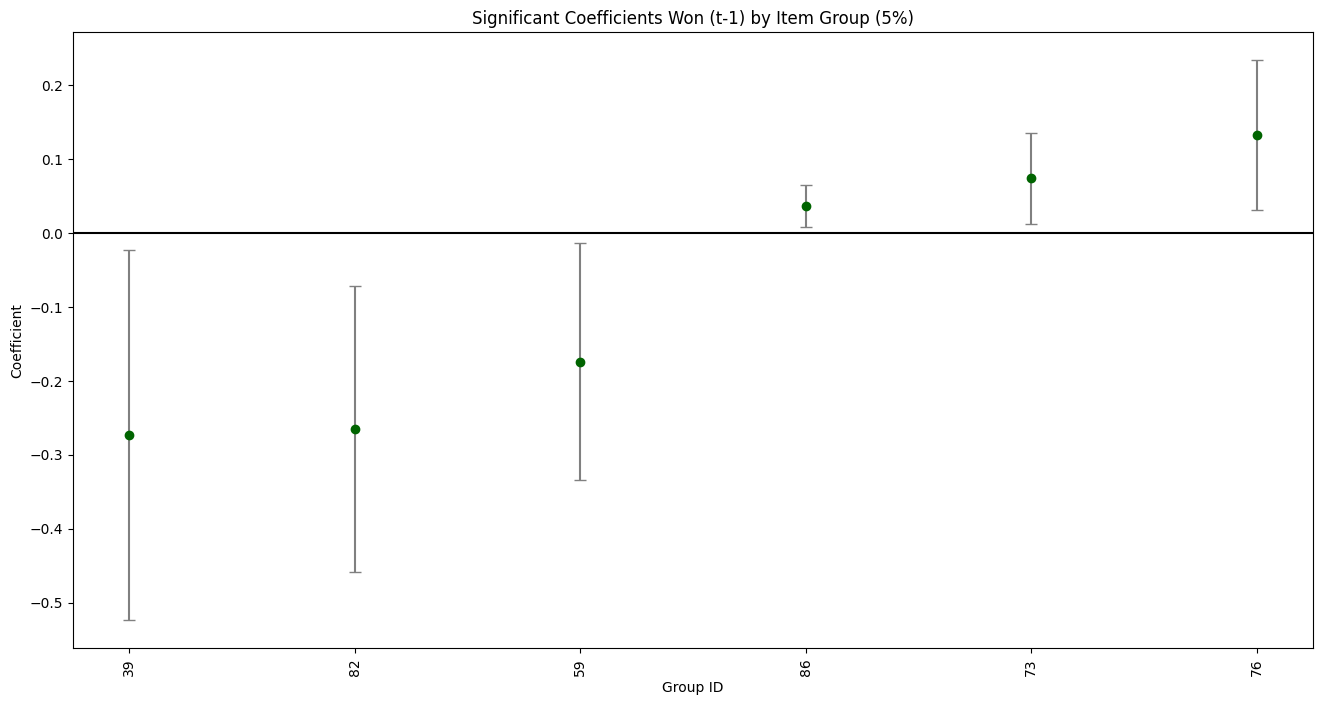

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_won = df_won.rename(columns={' Group Item': 'group_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant = df_won[df_won['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant = df_significant.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant)), df_significant['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkgreen', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Group ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Won (t-1) by Item Group (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant)), df_significant['group_id'].astype(str), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_won_t_minus_1_group_item_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()


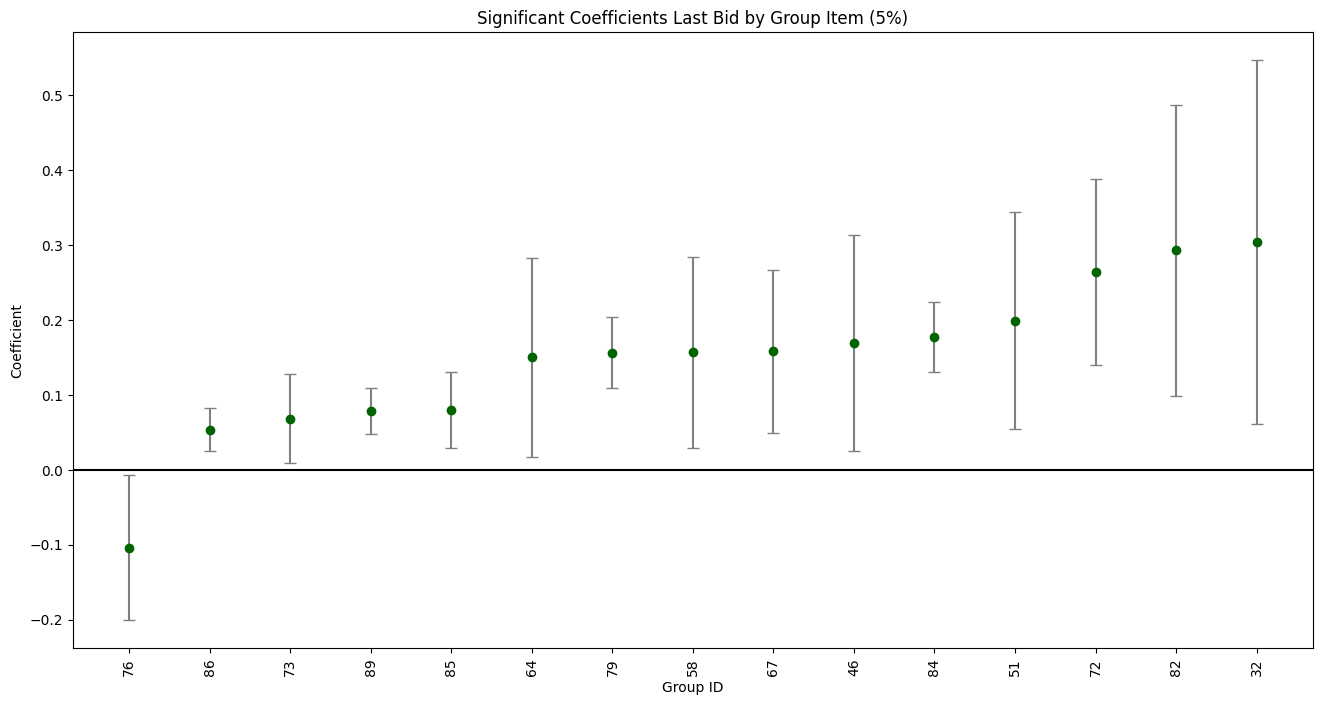

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_last = df_last.rename(columns={' Group Item': 'group_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})
df_last['group_id'] = df_last['group_id'].astype(int)

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_last = df_last[df_last['sig_5pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_last = df_significant_last.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_last['std_error'] * 1.96

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_last)), df_significant_last['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkgreen', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Group ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Last Bid by Group Item (5%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_last)), df_significant_last['group_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_last_bid_group_item_5pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

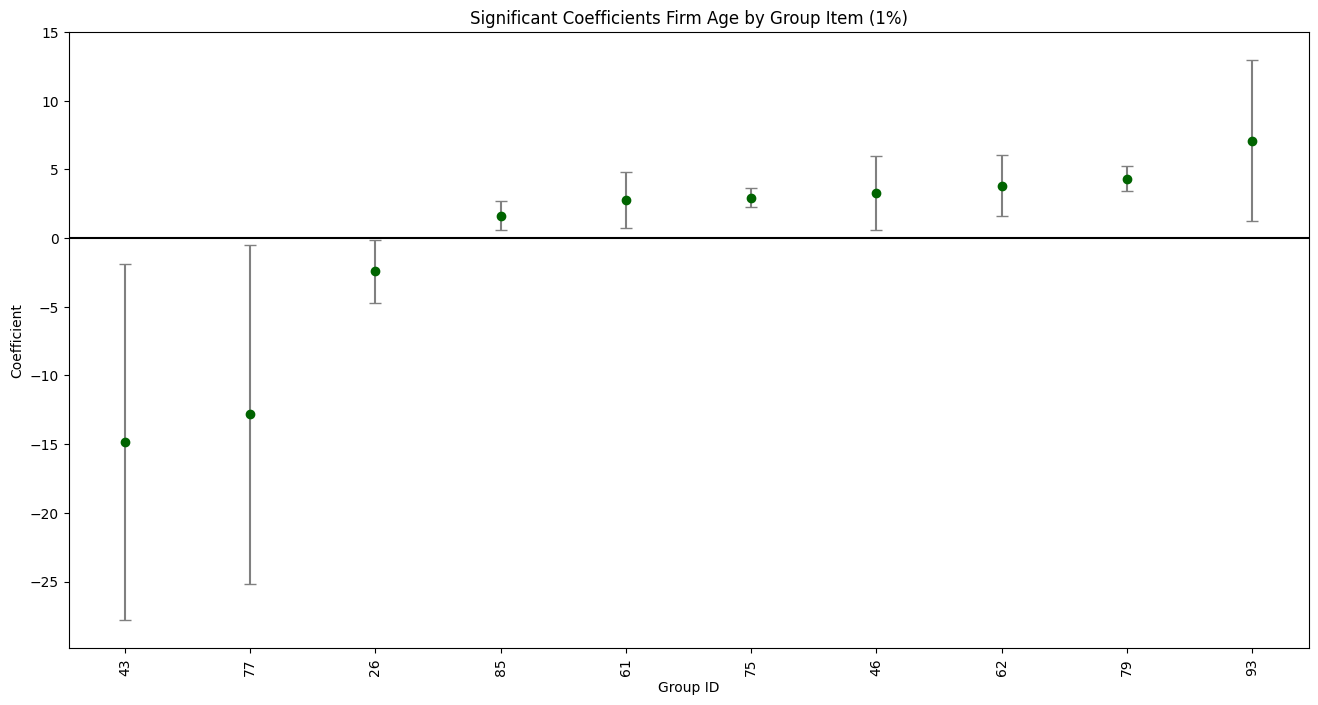

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_age = df_age.rename(columns={' Group Item': 'group_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_age = df_age[df_age['sig_1pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_age = df_significant_age.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_age['std_error'] * 2.54

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_age)), df_significant_age['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkgreen', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Group ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Firm Age by Group Item (1%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_age)), df_significant_age['group_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_age_group_item_1pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

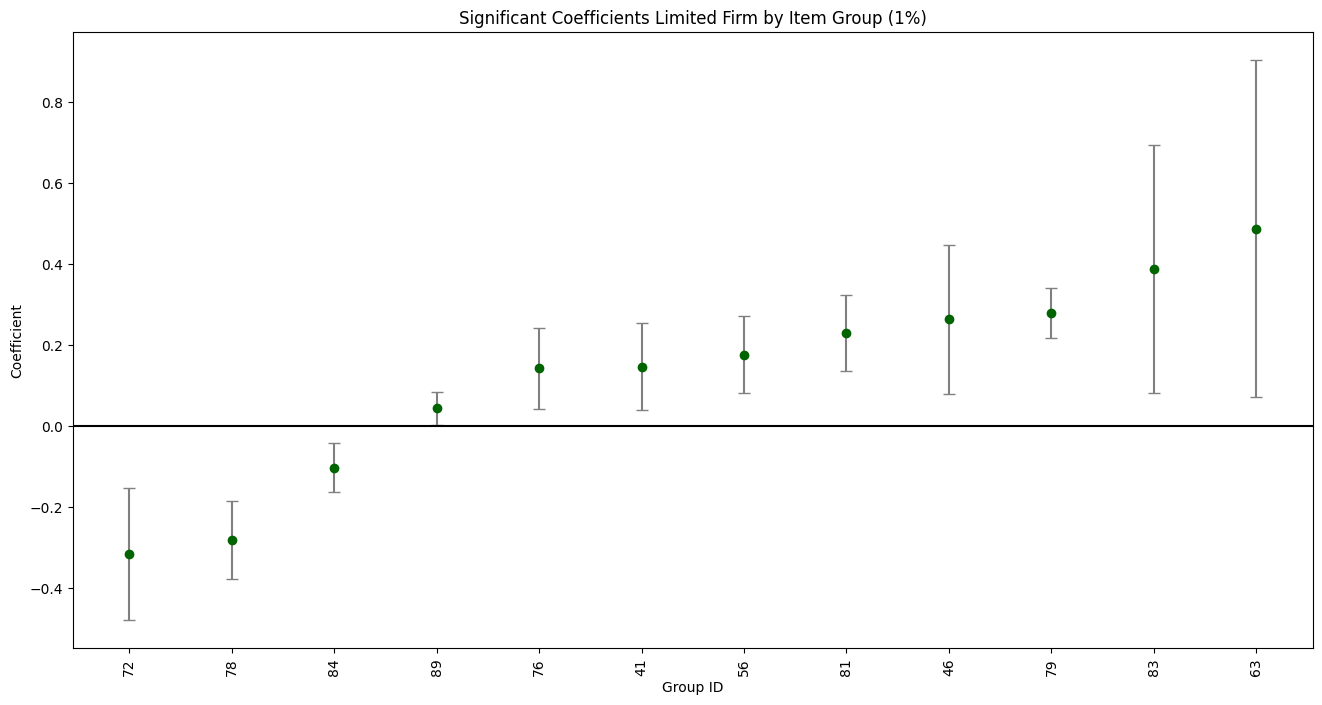

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Rename columns if needed to match the example
df_lim_firm = df_lim_firm.rename(columns={' Group Item': 'group_id', ' Coefficient': 'coefficient', ' Std. Error': 'std_error', ' Sig_1pct': 'sig_1pct', ' Sig_5pct': 'sig_5pct', ' Sig_10pct': 'sig_10pct'})

# Filter rows for significant coefficients (assuming 'sig_1pct' indicates significance)
df_significant_lim = df_lim_firm[df_lim_firm['sig_1pct'] == 1]

# Sort the dataframe by 'coefficient' in ascending order
df_significant_lim = df_significant_lim.sort_values(by='coefficient', ascending=True)

# Calculate 95% confidence intervals
ci_95 = df_significant_lim['std_error'] * 2.54

# Plot the coefficients with error bars
plt.figure(figsize=(16, 8))
plt.errorbar(range(len(df_significant_lim)), df_significant_lim['coefficient'],  # Use range of sorted index for evenly spaced ticks
             yerr=ci_95, fmt='o', color='darkgreen', 
             ecolor='gray', capsize=4)

# Add a vertical line at y=0
plt.axhline(y=0, color='black')

# Labels and title
plt.xlabel('Group ID')
plt.ylabel('Coefficient')
plt.title('Significant Coefficients Limited Firm by Item Group (1%)')

# Set the x-ticks to correspond to the sorted market_id values
plt.xticks(range(len(df_significant_lim)), df_significant_lim['group_id'].astype(int), rotation=90)

# Save the plot as a .pdf file (optional)
#plt.savefig('/Users/dvacchini/Library/CloudStorage/Dropbox/Projects_Brazilian_data/Dario_vacchini/output/graphs/coef_sig_limited_firm_item_group_1pct.pdf', bbox_inches='tight', dpi=300)

plt.show()

In [7]:
# Positive coefficient for market - sig: 0.01

positive_significant_markets_won_1 = df_won[(df_won['sig_1pct']==1) & (df_won['coefficient'] > 0)]['group_id'].tolist()
print("won_t_minus_1 (0.01):", positive_significant_markets_won_1)

positive_significant_markets_last_1 = df_last[(df_last['sig_1pct']==1) & (df_last['coefficient'] > 0)]['group_id'].tolist()
print("last (0.01):", positive_significant_markets_last_1)

positive_significant_markets_age_1 = df_age[(df_age['sig_1pct']==1) & (df_age['coefficient'] > 0)]['group_id'].astype(int).to_list()
print("age (0.01):", positive_significant_markets_age_1)

positive_significant_markets_lim_1 = df_lim_firm[(df_lim_firm['sig_1pct']==1) & (df_lim_firm['coefficient'] > 0)]['group_id'].astype(int).to_list()
print("limited_firm (0.01):", positive_significant_markets_lim_1)

won_t_minus_1 (0.01): []
last (0.01): [51, 67, 72, 79, 82, 84, 85, 86, 89]
age (0.01): [46, 61, 62, 75, 79, 85, 93]
limited_firm (0.01): [41, 46, 56, 63, 76, 79, 81, 83, 89]


In [8]:
# Positive coefficient for market - sig: 0.05

positive_significant_markets_won_5 = df_won[(df_won['sig_5pct']==1) & (df_won['coefficient'] > 0)]['group_id'].tolist()
print("won_t_minus_1 (0.05):", positive_significant_markets_won_5)

positive_significant_markets_last_5 = df_last[(df_last['sig_5pct']==1) & (df_last['coefficient'] > 0)]['group_id'].tolist()
print("last (0.05):", positive_significant_markets_last_5)

positive_significant_markets_age_5 = df_age[(df_age['sig_5pct']==1) & (df_age['coefficient'] > 0)]['group_id'].astype(int).to_list()
print("age (0.05):", positive_significant_markets_age_5)

positive_significant_markets_lim_5 = df_lim_firm[(df_lim_firm['sig_5pct']==1) & (df_lim_firm['coefficient'] > 0)]['group_id'].astype(int).to_list()
print("limited_firm (0.05):", positive_significant_markets_lim_5)

won_t_minus_1 (0.05): [73, 76, 86]
last (0.05): [32, 46, 51, 58, 64, 67, 72, 73, 79, 82, 84, 85, 86, 89]
age (0.05): [46, 61, 62, 75, 79, 85, 91, 93]
limited_firm (0.05): [41, 46, 56, 63, 73, 76, 79, 81, 83, 86, 89]


In [9]:
# Positive coefficient for market - sig: 0.10

positive_significant_markets_won_10 = df_won[(df_won['sig_10pct']==1) & (df_won['coefficient'] > 0)]['group_id'].tolist()
print("won_t_minus_1 (0.10):", positive_significant_markets_won_10)

positive_significant_markets_last_10 = df_last[(df_last['sig_10pct']==1) & (df_last['coefficient'] > 0)]['group_id'].tolist()
print("last (0.10):", positive_significant_markets_last_10)

positive_significant_markets_age_10 = df_age[(df_age['sig_10pct']==1) & (df_age['coefficient'] > 0)]['group_id'].astype(int).to_list()
print("age (0.10):", positive_significant_markets_age_10)

positive_significant_markets_lim_10 = df_lim_firm[(df_lim_firm['sig_10pct']==1) & (df_lim_firm['coefficient'] > 0)]['group_id'].astype(int).to_list()
print("limited_firm (0.10):", positive_significant_markets_lim_10)

won_t_minus_1 (0.10): [67, 69, 73, 76, 86]
last (0.10): [32, 42, 46, 51, 56, 58, 64, 67, 72, 73, 74, 79, 82, 84, 85, 86, 89]
age (0.10): [27, 46, 47, 58, 61, 62, 75, 79, 82, 85, 91, 93]
limited_firm (0.10): [32, 41, 46, 51, 56, 58, 63, 73, 75, 76, 79, 81, 82, 83, 86, 89]


In [10]:
# Common market -- sig: 0.01 

won_t_minus_1_age_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_age_1))
print("won_t_minus_1 - age (0.01):", won_t_minus_1_age_1)

won_t_minus_1_limited_firm_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_lim_1))
print("won_t_minus_1 - limited_firm (0.01):", won_t_minus_1_limited_firm_1)

last_age_1 = list(set(positive_significant_markets_last_1) & set(positive_significant_markets_age_1))
print("last - age (0.01):", last_age_1)

last_limited_firm_1 = list(set(positive_significant_markets_last_1) & set(positive_significant_markets_lim_1))
print("last - limited_firm (0.01):", last_limited_firm_1)

won_t_minus_1_last_1 = list(set(positive_significant_markets_won_1) & set(positive_significant_markets_last_1))
print("won_t_minus_1 - last (0.01):", won_t_minus_1_last_1)

won_t_minus_1 - age (0.01): []
won_t_minus_1 - limited_firm (0.01): []
last - age (0.01): [85, 79]
last - limited_firm (0.01): [89, 79]
won_t_minus_1 - last (0.01): []


In [11]:
# Common market -- sig: 0.05

won_t_minus_1_age_5 = list(set(positive_significant_markets_won_5) & set(positive_significant_markets_age_5))
print("won_t_minus_1 - age (0.05):", won_t_minus_1_age_5)

won_t_minus_1_limited_firm_5 = list(set(positive_significant_markets_won_5) & set(positive_significant_markets_lim_5))
print("won_t_minus_1 - limited_firm (0.05):", won_t_minus_1_limited_firm_5)

last_age_5 = list(set(positive_significant_markets_last_5) & set(positive_significant_markets_age_5))
print("last - limited_firm (0.05):", last_age_5)

last_limited_firm_5 = list(set(positive_significant_markets_last_5) & set(positive_significant_markets_lim_5))
print("last - limited_firm (0.05):", last_limited_firm_5)

won_t_minus_1 - age (0.05): []
won_t_minus_1 - limited_firm (0.05): [73, 76, 86]
last - limited_firm (0.05): [85, 46, 79]
last - limited_firm (0.05): [73, 46, 79, 86, 89]


In [12]:
# Common market -- sig: 0.10

won_t_minus_1_age_10 = list(set(positive_significant_markets_won_10) & set(positive_significant_markets_age_10))
print("won_t_minus_1 - age (0.10):", won_t_minus_1_age_10)

won_t_minus_1_limited_firm_10 = list(set(positive_significant_markets_won_10) & set(positive_significant_markets_lim_10))
print("won_t_minus_1 - limited_firm (0.10):", won_t_minus_1_limited_firm_10)

last_age_10 = list(set(positive_significant_markets_last_10) & set(positive_significant_markets_age_10))
print("last - limited_firm (0.10):", last_age_10)

last_limited_firm_10 = list(set(positive_significant_markets_last_10) & set(positive_significant_markets_lim_10))
print("last - limited_firm (0.10):", last_limited_firm_10)

won_t_minus_1 - age (0.10): []
won_t_minus_1 - limited_firm (0.10): [73, 76, 86]
last - limited_firm (0.10): [46, 79, 82, 85, 58]
last - limited_firm (0.10): [32, 73, 46, 79, 82, 51, 86, 56, 89, 58]
